<h1 style="text-align:center; font-weight:bold; color:pink;">
Data Visualization before preprocessing
</h1>

___

In [1]:
import os
import shutil
import random
from pathlib import Path
from PIL import Image, ImageEnhance, ImageFilter
import matplotlib.pyplot as plt

In [2]:
SOURCE_PATH = r"Garbage_Classification"
OUTPUT_PATH = r"C:\Users\e\Desktop\NN_Data_set"
CLASSES = ["Battery","Cardboard","Clothes","Glass","Metal","Paper","Plastic"]

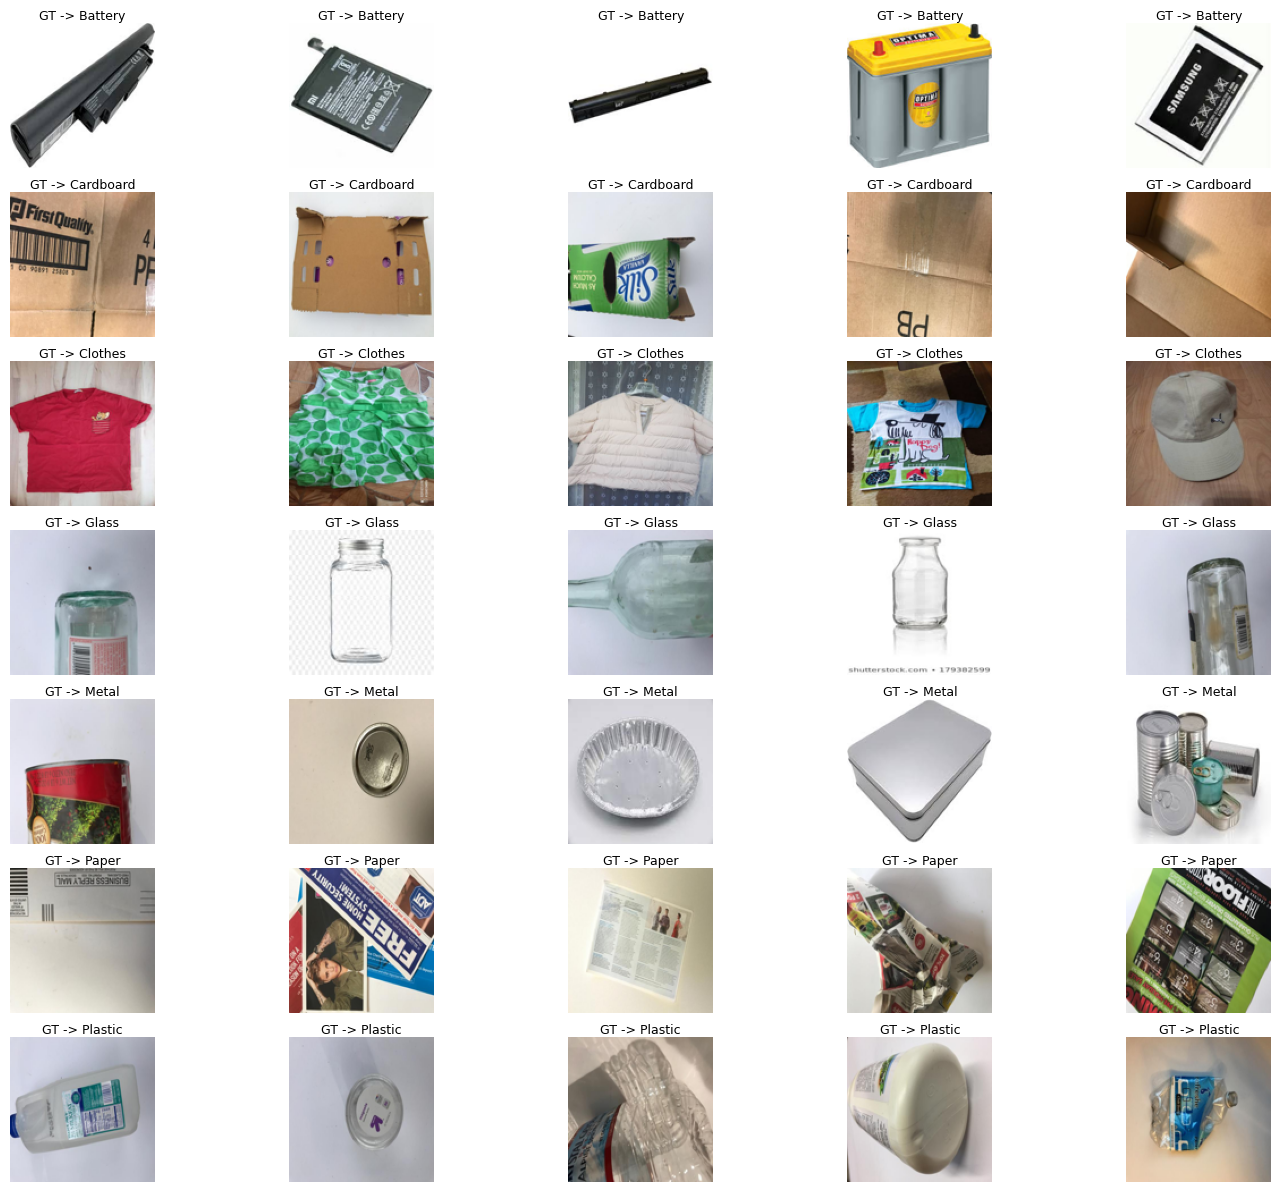

In [3]:
def show_before():
    plt.figure(figsize=(15, 12))
    cols = 5
    rows = len(CLASSES)
    IMAGE_SIZE = (128, 128)

    for i, cls in enumerate(CLASSES):
        path = Path(SOURCE_PATH, cls)

        if not path.exists():
            print(f" Path not found {path}")
            continue

        imgs = list(path.glob("*.*"))

        num_to_sample = min(len(imgs), cols)

        if num_to_sample > 0:
            sample = random.sample(imgs, num_to_sample)

            for j, img_path in enumerate(sample):
                img = Image.open(img_path)
                img = img.resize(IMAGE_SIZE)
                plt.subplot(rows, cols, i * cols + j + 1)
                plt.imshow(img)
                plt.axis("off")
                plt.title(f"GT -> {cls}", fontsize=9, pad=2)
        else:
            print(f"folder {cls} is empty.")
    plt.tight_layout(pad=1.0, h_pad=0.8, w_pad=0.8)
    plt.show()

show_before()

<h1 style="text-align:center; font-weight:bold; color:pink;">
Data Splitting & Preprocessing
</h1>

___

In [ ]:
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15
RANDOM_SEED = 42

In [28]:
print("Number of images in each class:")
print("-" * 35)
for cls in CLASSES:
    imgs = list(Path(SOURCE_PATH, cls).glob("*.jpg"))
    print(f"  {cls:<12}: {len(imgs)} images")
print("-" * 35)

Number of images in each class:
-----------------------------------
  Battery     : 697 images
  Cardboard   : 660 images
  Clothes     : 652 images
  Glass       : 677 images
  Metal       : 675 images
  Paper       : 676 images
  Plastic     : 664 images
-----------------------------------


In [29]:
for split in ["train", "val", "test"]:
    for cls in CLASSES:
        Path(OUTPUT_PATH, split, cls).mkdir(parents=True, exist_ok=True)


In [ ]:
HARD_CLASSES = ["Glass", "Metal", "Plastic"]

base_ops = [
    lambda x: x.transpose(Image.FLIP_LEFT_RIGHT),
    lambda x: x.rotate(random.uniform(-10, 10)),
    lambda x: ImageEnhance.Brightness(x).enhance(random.uniform(0.9, 1.1)),
    lambda x: ImageEnhance.Contrast(x).enhance(random.uniform(0.9, 1.1)),
]

hard_ops = [
    lambda x: x.transpose(Image.FLIP_LEFT_RIGHT),
    lambda x: x.rotate(random.uniform(-15, 15)),
    lambda x: ImageEnhance.Brightness(x).enhance(random.uniform(0.85, 1.15)),
    lambda x: ImageEnhance.Contrast(x).enhance(random.uniform(0.85, 1.15)),
]

def augment_image(img, class_name):

    if class_name in HARD_CLASSES:
        ops = hard_ops
        k = random.randint(2, 3)
    else:
        ops = base_ops
        k = random.randint(1, 2)

    chosen_ops = random.sample(ops, k=k)

    for op in chosen_ops:
        img = op(img)

    return img

In [31]:
import os, random, shutil
from pathlib import Path

random.seed(42) 

for split in ["train", "val", "test"]:
    for cls in CLASSES:
        os.makedirs(Path(OUTPUT_PATH, split, cls), exist_ok=True)

train_data_paths = {}

for cls in CLASSES:
    imgs = list(Path(SOURCE_PATH, cls).glob("*.*"))
    random.shuffle(imgs)
    
    train_end = int(len(imgs) * TRAIN_RATIO)
    val_end   = train_end + int(len(imgs) * VAL_RATIO)

    train_imgs = imgs[:train_end]
    val_imgs   = imgs[train_end:val_end]
    test_imgs  = imgs[val_end:]

    
    for img in val_imgs: shutil.copy2(img, Path(OUTPUT_PATH, "val", cls, img.name))
    for img in test_imgs: shutil.copy2(img, Path(OUTPUT_PATH, "test", cls, img.name))
    for img in train_imgs: shutil.copy2(img, Path(OUTPUT_PATH, "train", cls, img.name))

    train_data_paths[cls] = train_imgs
    print(f"{cls:<12}: train={len(train_imgs)} | val={len(val_imgs)} | test={len(test_imgs)}")

target_train = max(len(imgs) for imgs in train_data_paths.values())

Battery     : train=487 | val=104 | test=106
Cardboard   : train=461 | val=99 | test=100
Clothes     : train=456 | val=97 | test=99
Glass       : train=473 | val=101 | test=103
Metal       : train=472 | val=101 | test=102
Paper       : train=473 | val=101 | test=102
Plastic     : train=464 | val=99 | test=101


In [32]:
HARD_CLASSES = ["Glass", "Metal", "Plastic"]

for cls, train_imgs in train_data_paths.items():

    if cls in HARD_CLASSES:
        multiplier = 1.3
    else:
        multiplier = 1.2

    final_target = int(len(train_imgs) * multiplier)
    needed = max(0, final_target - len(train_imgs))

    aug_count = 0

    print(f"Working on {cls}... Creating {needed} augmented images.")

    random.shuffle(train_imgs)

    idx = 0

    while aug_count < needed:

        if idx >= len(train_imgs):
            random.shuffle(train_imgs)
            idx = 0

        src = train_imgs[idx]
        idx += 1

        try:
            img = Image.open(src).convert("RGB")
            aug_img = augment_image(img, cls)

            aug_name = f"aug_{aug_count}_{src.stem}.jpg"
            save_path = Path(OUTPUT_PATH, "train", cls, aug_name)

            aug_img.save(save_path)

            aug_count += 1

        except Exception as e:
            print(f"Error processing {src}: {e}")
            continue

    print(f"Finished {cls}: total ≈ {len(train_imgs) + aug_count}")

Working on Battery... Creating 97 augmented images.
Finished Battery: total ≈ 584
Working on Cardboard... Creating 92 augmented images.
Finished Cardboard: total ≈ 553
Working on Clothes... Creating 91 augmented images.
Finished Clothes: total ≈ 547
Working on Glass... Creating 141 augmented images.
Finished Glass: total ≈ 614
Working on Metal... Creating 141 augmented images.
Finished Metal: total ≈ 613
Working on Paper... Creating 94 augmented images.
Finished Paper: total ≈ 567
Working on Plastic... Creating 139 augmented images.
Finished Plastic: total ≈ 603


In [33]:
orig_trains = sum(
    int(len(list(Path(SOURCE_PATH, cls).glob("*.*"))) * TRAIN_RATIO)
    for cls in CLASSES
)
orig_val  = sum(len(list(Path(OUTPUT_PATH, "val",  cls).glob("*.*"))) for cls in CLASSES)
orig_test = sum(len(list(Path(OUTPUT_PATH, "test", cls).glob("*.*"))) for cls in CLASSES)
aug_train = sum(len(list(Path(OUTPUT_PATH, "train", cls).glob("*.*"))) for cls in CLASSES)

total_orig = orig_trains + orig_val + orig_test

print("="*50)
print(f"{'Final Data Distribution Report':^50}")
print("-" * 50)
augmentation_factor = aug_train / orig_trains

print(f"  Train (Augmented) : {aug_train:<6} images ({augmentation_factor:.2f}x original)")
print(f"  Validation       : {orig_val:<6} images ({orig_val/total_orig*100:.1f}% of total)")
print(f"  Test             : {orig_test:<6} images ({orig_test/total_orig*100:.1f}% of total)")
print("-" * 50)
print(f"  Total Images (System wide): {aug_train + orig_val + orig_test}")
print(f"  Original Dataset Size     : {total_orig}")
print("="*50)

          Final Data Distribution Report          
--------------------------------------------------
  Train (Augmented) : 4081   images (1.24x original)
  Validation       : 702    images (14.9% of total)
  Test             : 713    images (15.2% of total)
--------------------------------------------------
  Total Images (System wide): 5496
  Original Dataset Size     : 4701


<h1 style="text-align:center; font-weight:bold; color:pink;">
Data Visualization after preprocessing
</h1>

___

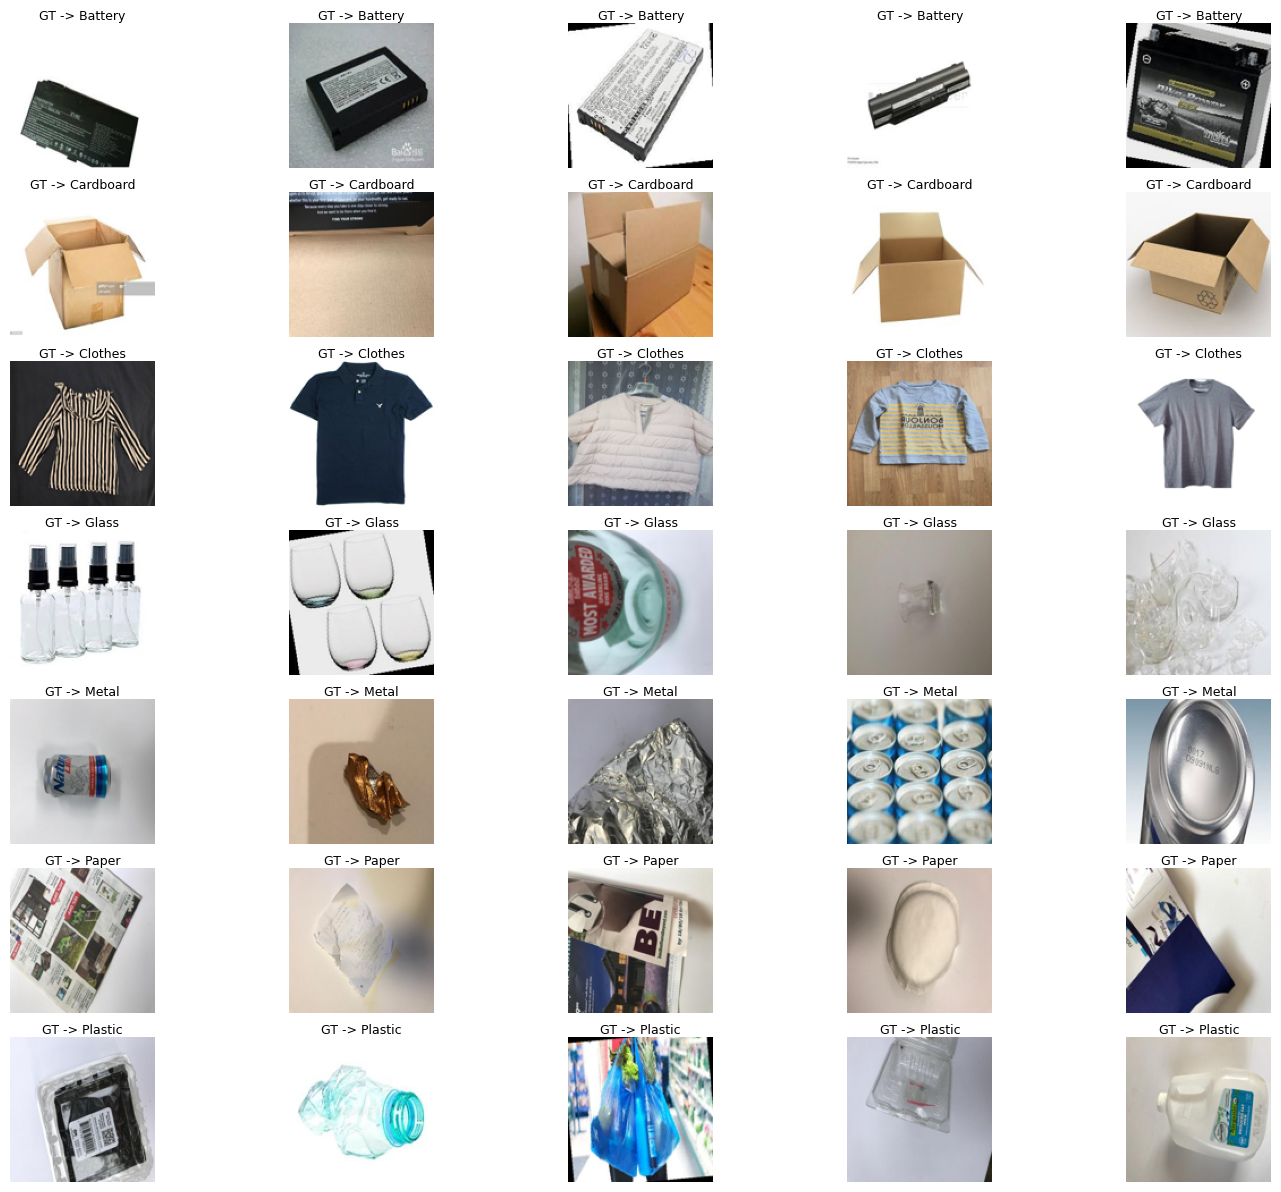

In [ ]:
def show_after():
    plt.figure(figsize=(15, 12))
    cols = 5
    rows = len(CLASSES)

    IMAGE_SIZE = (128, 128)

    for i, cls in enumerate(CLASSES):
        path = Path("NN_Data_set", "train", cls)

        if not path.exists():
            continue

        imgs = list(path.glob("*.*"))

        num_to_sample = min(len(imgs), cols)

        if num_to_sample > 0:
            sample = random.sample(imgs, num_to_sample)

            for j, img_path in enumerate(sample):
                img = Image.open(img_path)

                img = img.resize(IMAGE_SIZE)
                plt.subplot(rows, cols, i * cols + j + 1)
                plt.imshow(img)
                plt.axis("off")
                plt.title(f"GT -> {cls}", fontsize=9, pad=2)
        else:
            print(f"Warning: No images found in {cls}")
    plt.tight_layout(pad=1.0, h_pad=0.8, w_pad=0.8)
    plt.show()

show_after()